### Setup base model and data

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os
from sklearn.ensemble import RandomForestClassifier

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
def score_matrix(Xa):
    return -np.log(model.predict_proba(Xa) + 1e-12)

### Training a model of coverage levels

In [3]:
# set up for ablation - determine uncertainty methods to use
from ablation_utils.uncertainty import (
    UncertaintyData, ConstantEU, KNNRadius, MMIUncertainty, conformal_pvalues_loo, conformal_pvalues
)

uncertainty_methods = {
    "constant": ConstantEU(),
    "knn":      KNNRadius(n_neighbors=25, standardize=True),
    "mmi_pi":   MMIUncertainty(form="pi"),
}

In [4]:
# Leave exactly one `data = ...` block uncommented

from ablation_utils.data import blobs, pendigits, fashion_mnist

data = pendigits(eu_classes=(5, 6, 7, 8, 9), eu_keep=0.25, seed=0)
dataname="PENDIGITS"
#data = blobs(eu_classes=(5, 6, 7, 8), eu_keep=0.1, seed=0)
#dataname="BLOBS"
#data = fashion_mnist(eu_keep=0.3, n_train=10000, n_calib=5000, n_test=20000,seed=0)
#dataname="FASHION_MNIST"


X_train, y_train = data.X_train, data.y_train
X_calib, y_calib = data.X_calib, data.y_calib
X_test,  y_test  = data.X_test,  data.y_test

num_classes = data.num_classes
n_calib     = data.n_calib
group_test   = data.group_test      

print(data.summary())

pendigits: K = 10, n_train = 3785, n_calib = 1000, n_test = 3000
  eu classes     [5, 6, 7, 8, 9]
  train / class  [612, 614, 635, 564, 622, 146, 143, 163, 144, 142]
  rest   train   3047   test   1572
  eu     train    738   test   1428


In [5]:
def scores_all(Xa):
    """(m, K) matrix of S(x, y) for every candidate label y."""
    return 1.0 - model.predict_proba(Xa)


model = RandomForestClassifier()
model.fit(X_train, y_train)

S_calib_all = scores_all(X_calib)                    # (n_calib, K)
S_calib = S_calib_all[np.arange(n_calib), y_calib]   # (n_calib,)
S_test_all = scores_all(X_test)
S_test  = S_test_all[np.arange(len(X_test)), y_test]
acc = model.score(X_train, y_train)

print("base model accuracy (calib):", (model.predict(X_calib) == y_calib).mean())

base model accuracy (calib): 0.983


In [6]:
# construct the loo data needed for all uncertainty methods

n_loo = n_calib - 1
Sigma_loo = S_calib.sum() - S_calib                
E_loo = (n_loo + 1) * S_calib_all / (Sigma_loo[:, None] + S_calib_all)   
feats_loo = np.concatenate([Sigma_loo[:, None], np.sort(S_calib_all, axis=1)], axis=1)
P_loo     = conformal_pvalues_loo(S_calib, S_calib_all)
# bundle the calibration data
train_data = UncertaintyData(X=X_train)
calib_data = UncertaintyData(X=X_calib, E=E_loo, S=S_calib_all, P=P_loo)

for method in uncertainty_methods.values():
    method.fit(train_data).calibrate(calib_data)


c:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

In [7]:
import ablation_utils.neural_net as anet

# ablation config
train_loaders = {
    name: anet.make_loader(
        Sigma = Sigma_loo,
        S     = S_calib_all,
        E     = E_loo,
        u     = method.transform_loo(calib_data),
        batch_size = 32,
    )
    for name, method in uncertainty_methods.items()
}
# optimal lam changes with dataset
num_runs, num_epochs, lr = 4, 200, 1e-3
print(f"highest recommended lambda: {(num_classes-1) * E_loo.max()}")
lam=int(((num_classes-1) * E_loo.max())//5)*5

highest recommended lambda: 75.79585649317836


In [8]:

ablation = anet.run_uncertainty_ablation(
    train_loaders, lam=lam, num_epochs=num_epochs,
    lr=lr, num_runs=num_runs, device=device, patience=20
)


[constant] run 1/4
  lam 75 | run 1 | epoch 0/200 | loss 18.1315 | size 1.3921 | alpha 0.2232
  lam 75 | run 1 | epoch 25/200 | loss 11.4470 | size 1.5046 | alpha 0.1326
  lam 75 | run 1 | epoch 50/200 | loss 11.4177 | size 1.4687 | alpha 0.1327
  lam 75 | run 1 | epoch 75/200 | loss 11.4202 | size 1.4698 | alpha 0.1327
  early stop at epoch 81

[constant] run 2/4
  lam 75 | run 2 | epoch 0/200 | loss 13.4744 | size 1.4692 | alpha 0.1601
  lam 75 | run 2 | epoch 25/200 | loss 11.4379 | size 1.5080 | alpha 0.1324
  lam 75 | run 2 | epoch 50/200 | loss 11.4224 | size 1.4703 | alpha 0.1327
  lam 75 | run 2 | epoch 75/200 | loss 11.4195 | size 1.4424 | alpha 0.1330
  lam 75 | run 2 | epoch 100/200 | loss 11.4120 | size 1.4241 | alpha 0.1332
  early stop at epoch 107

[constant] run 3/4
  lam 75 | run 3 | epoch 0/200 | loss 17.2535 | size 1.5441 | alpha 0.2095
  lam 75 | run 3 | epoch 25/200 | loss 11.4352 | size 1.5036 | alpha 0.1324
  lam 75 | run 3 | epoch 50/200 | loss 11.4227 | size 1

c:\Users\User\Documents\learning-uncertainty-aware-policies\classification\neural_net.py:445: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


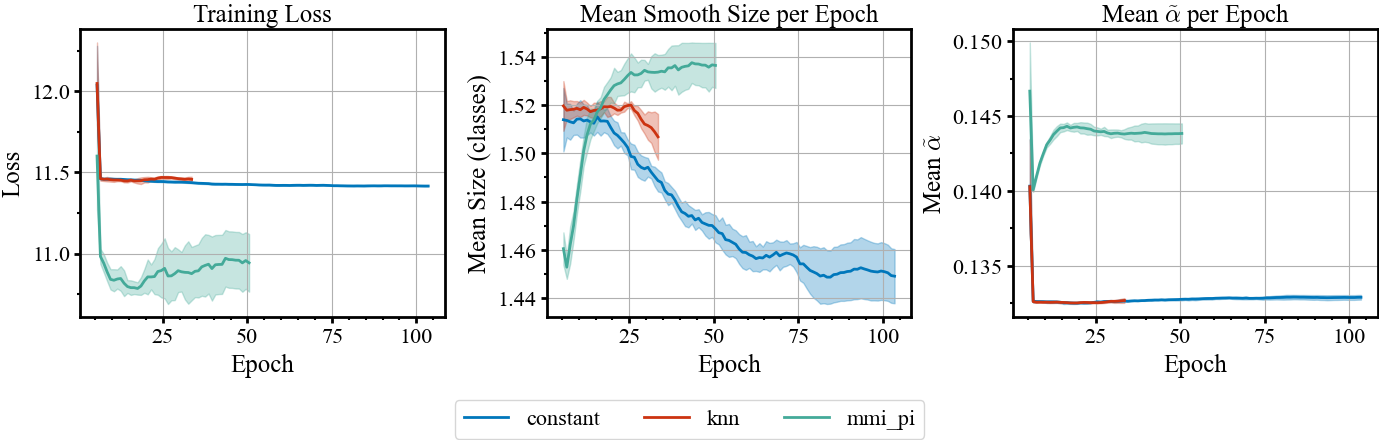

In [9]:
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import AutoMinorLocator
from tueplots import bundles

os.makedirs("plots", exist_ok=True)


anet.plot_performance(ablation, path=f"plots/alpha_net_results_uq_ablation_{dataname}_data.pdf")

### Exact optimal coverage policy

A candidate $y$ enters the set when its soft-rank e-value is below the threshold:

$$\frac{(n+1)\,S(x,y)}{\Sigma + S(x,y)} \le \frac{1}{\tilde\alpha}
\iff S(x,y) \le \tau(\tilde\alpha) := \frac{\Sigma}{(n+1)\tilde\alpha - 1},
\qquad \Sigma := \sum_{i=1}^{n} S(X_i, Y_i),\qquad \tilde\alpha > \tfrac{1}{n+1}$$

With sorted candidate scores $s_{(1)} \le \dots \le s_{(K)}$ at a test point,
the optimum can be found by iterating through the breakpoints

$$\beta_j = \frac{1}{n+1}\left(\frac{\Sigma}{s_{(j)}} + 1\right),\qquad \beta_1 \ge \beta_2 \ge \dots \ge \beta_K .$$




In [35]:
# exact minimiser of L(alpha) = Size(alpha) + lambda * alpha 
def exact_size(Sigma, s_cand, n, alpha):
    if alpha <= 1.0 / (n + 1):
        return len(s_cand)                      
    tau = Sigma / ((n + 1) * alpha - 1.0)
    return int(np.sum(s_cand <= tau))

def covered(Sigma, s_true, n, alpha):
    E_true = (n + 1) * s_true / (Sigma + s_true)
    return E_true <= 1.0 / alpha

def exact_min(Sigma, s_cand, n, lam, w=1.0, eps=1e-6):
    """Exact minimiser of Size(a) + lam * w * a over (1/(n+1), 1]. Returns (alpha*, L*).
    w = c(u(x)) at this point; w=1 recovers the EU-unaware objective."""
    s_sorted = np.sort(s_cand)
    breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)          
    cands = np.concatenate([breakpoints + eps, [1.0 / (n + 1) + eps, 1.0]])
    cands = np.unique(cands[(cands > 1.0 / (n + 1)) & (cands <= 1.0)])
    losses = np.array([exact_size(Sigma, s_cand, n, a) + lam * w * a for a in cands])
    j = int(np.argmin(losses))
    return float(cands[j]), float(losses[j])

def per_point(alphas, Sigma=Sigma_loo, S_all=S_calib_all, S_true=S_calib, n=n_loo):
    sizes = np.array([exact_size(Sigma[i], S_all[i], n, alphas[i]) for i in range(len(alphas))])
    miss  = np.array([not covered(Sigma[i], S_true[i], n, alphas[i]) for i in range(len(alphas))])
    return sizes, miss

def evaluate_policy(Sigma_arr, S_all, S_true, n, alphas):
    """alphas: (m,) per-point levels. Sigma_arr: (m,) array or scalar (broadcast).
    Returns mean alpha, mean exact size, empirical miscoverage."""
    m = len(alphas)
    Sigma_arr = np.broadcast_to(Sigma_arr, (m,))
    sizes = np.array([exact_size(Sigma_arr[i], S_all[i], n, alphas[i]) for i in range(m)])
    miss  = np.array([not covered(Sigma_arr[i], S_true[i], n, alphas[i]) for i in range(m)])
    return float(np.mean(alphas)), float(sizes.mean()), float(miss.mean())

def evaluate_policy_loo(alphas, Sigma=Sigma_loo, S_all=S_calib_all, S_true=S_calib, n=n_loo):
    """LOO episodes: episode i calibrates on the other n_loo points (sum Sigma_loo[i])
    and is tested on held-out point i with true-label score S_calib[i].
    Returns (mean alpha, mean exact size, empirical miscoverage)."""
    return evaluate_policy(Sigma, S_all, S_true, n, np.asarray(alphas, dtype=float))

def learned_alphas(net, feats):
    """feats: (m, d) array from anet.make_features -- same columns the net was trained on."""
    net.eval()
    with torch.no_grad():
        t = torch.as_tensor(np.asarray(feats), dtype=torch.float32).to(device)
        return net(t).cpu().numpy().reshape(-1)

def set_metrics_exact(alphas, sizes, miss, u, lam, c=1):
    a_mean  = float(alphas.mean())
    cov     = 1.0 - float(miss.mean())
    nominal = 1.0 - a_mean
    return {
        "mean alpha":  a_mean,
        "nominal cov": nominal,
        "coverage":    cov,
        "gap":         cov - nominal,                               
        "mean size":   float(sizes.mean()),
        "% empty":     100.0 * float(np.mean(sizes == 0)),
        "EU unaware loss":        float(sizes.mean() + lam * a_mean),          
        "objective":   float(np.mean(sizes + lam * c * u * alphas)),
    }

OBJECTIVE  = "loss"   # key for the pointwise EU-aware objective; the stats cell reads comparison[...]["loss"]
Sigma_test = float(S_calib.sum())
E_test     = (n_calib + 1) * S_test_all / (Sigma_test + S_test_all)
test_data  = UncertaintyData(X=X_test, E=E_test, S=S_test_all,
                             P=conformal_pvalues(S_calib, S_test_all))
n_test = len(X_test)

EU_test = np.isin(y_test, data.eu_classes)
GROUPS = [("all", np.ones(n_test, bool)), ("high eu", EU_test), ("low eu", ~EU_test)]


print(f"Calibration set: n_calib = {n_calib}   (LOO episodes use n = {n_loo})")
print(f"Sigma over LOO episodes: mean {Sigma_loo.mean():.3f}, "
      f"range [{Sigma_loo.min():.3f}, {Sigma_loo.max():.3f}]\n")



Calibration set: n_calib = 1000   (LOO episodes use n = 999)
Sigma over LOO episodes: mean 118.561, range [117.740, 118.680]



In [ ]:
import pandas as pd

c = lambda u: u                      # c is the identity for now
names     = list(uncertainty_methods)
Sigma_col = np.full(n_test, Sigma_test)

comparison, rows, feats = {}, {}, {}

for name, method in uncertainty_methods.items():
    u  = np.asarray(method.transform_normalized(test_data), dtype=float).reshape(-1)
    cu = c(u)
    feats[name] = anet.make_features(Sigma_col, S_test_all, u)   # u(x) is a feature column

    # ---- exact: pointwise argmin of Size(a) + lam * c(u_i) * a ----
    a_ex = np.array([exact_min(Sigma_test, S_test_all[i], n_calib, lam, w=cu[i])[0]
                     for i in range(n_test)])
    s_ex, miss_ex = per_point(a_ex, Sigma=Sigma_col, S_all=S_test_all,
                              S_true=S_test, n=n_calib)
    loss_ex = s_ex + lam * cu * a_ex                                   # pointwise

    # ---- learned: one net per run ----
    a_nn_runs = np.stack([learned_alphas(net, feats[name]) for net in ablation[name]["nets"]])
    ev = [per_point(a, Sigma=Sigma_col, S_all=S_test_all, S_true=S_test, n=n_calib)
          for a in a_nn_runs]
    s_nn_runs    = np.stack([e[0] for e in ev]).astype(float)
    miss_nn_runs = np.stack([e[1] for e in ev]).astype(float)
    loss_nn_runs = s_nn_runs + lam * cu[None, :] * a_nn_runs

    comparison[name] = {
        "u": u,
        "exact":   {"alpha": a_ex, "size": s_ex.astype(float),
                    "miss": miss_ex.astype(float), OBJECTIVE: loss_ex},
        "learned": {"alpha": a_nn_runs.mean(0), "size": s_nn_runs.mean(0),
                    "miss": miss_nn_runs.mean(0), OBJECTIVE: loss_nn_runs.mean(0),
                    "alpha_runs": a_nn_runs, "size_runs": s_nn_runs,
                    "miss_runs": miss_nn_runs, "loss_runs": loss_nn_runs},
    }

    for g, m in GROUPS:
        for pol in ("exact", "learned"):
            d = comparison[name][pol]
            rows[(name, g, pol)] = set_metrics_exact(d["alpha"][m], d["size"][m],
                                                     d["miss"][m], u[m], lam)

table = pd.DataFrame(rows).T
table.index.names = ["method", "group", "policy"]
pd.set_option("display.width", 200)
print(table.round(4))

print("\nexcess loss of learned over exact (objective, group = all)")
for name in names:
    gap = rows[(name, "all", "learned")]["objective"] - rows[(name, "all", "exact")]["objective"]
    print(f"  {name:>12}  {gap:+.4f}")

print("\nsanity: exact alphas must vary across test points")
for name in names:
    a = comparison[name]["exact"]["alpha"]
    print(f"  {name:>12}  n_unique {len(np.unique(a)):>5}   "
          f"[{a.min():.3f}, {a.max():.3f}]   mean {a.mean():.3f}")


C:\Users\User\AppData\Local\Temp\ipykernel_21136\1990082405.py:16: RuntimeWarning: divide by zero encountered in divide
  breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)
C:\Users\User\AppData\Local\Temp\ipykernel_21136\1990082405.py:16: RuntimeWarning: divide by zero encountered in divide
  breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)


                          mean alpha  nominal cov  coverage     gap  mean size  % empty  EU unaware loss  objective
method   group   policy                                                                                            
constant all     exact        0.0528       0.9472    1.0000  0.0528     6.0790   0.0000          10.0404    10.0404
                 learned      0.1320       0.8680    0.9962  0.1282     1.2496   0.0000          11.1478    11.1478
         high eu exact        0.0286       0.9714    1.0000  0.0286     7.9139   0.0000          10.0607    10.0607
                 learned      0.1329       0.8671    0.9947  0.1276     1.3722   0.0000          11.3377    11.3377
         low eu  exact        0.0748       0.9252    1.0000  0.0748     4.4122   0.0000          10.0220    10.0220
                 learned      0.1312       0.8688    0.9976  0.1288     1.1382   0.0000          10.9752    10.9752
knn      all     exact        0.0698       0.9302    0.9997  0.0694     

C:\Users\User\AppData\Local\Temp\ipykernel_21136\2776943171.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


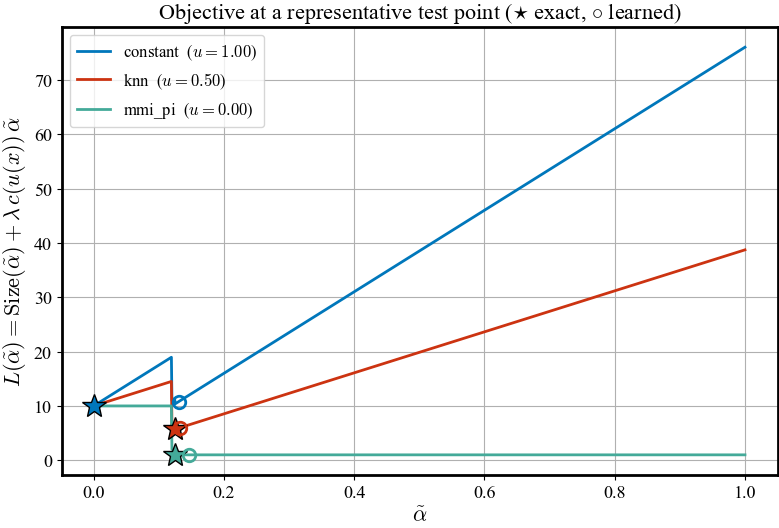

In [33]:
plt.rcParams.update(bundles.icml2024(usetex=False))
plt.rcParams.update({
    "axes.labelsize": 16, "axes.titlesize": 16,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 12, "lines.linewidth": 2, "axes.linewidth": 2,
})
colors = dict(zip(names, anet._PALETTE))

i_rep     = int(np.argsort(S_test)[len(S_test) // 2])   # median-difficulty test point
s_rep     = S_test_all[i_rep]
a_grid    = np.linspace(1.0 / (n_calib + 1) + 1e-3, 1.0, 1200)
size_grid = np.array([exact_size(Sigma_test, s_rep, n_calib, a) for a in a_grid], dtype=float)

fig, ax = plt.subplots(figsize=(8, 5.5))
for name in names:
    u_rep = float(comparison[name]["u"][i_rep])
    ax.plot(a_grid, size_grid + lam * c(u_rep) * a_grid, color=colors[name],
            label=rf"{name}  ($u={u_rep:.2f}$)")

    a_s, L_s = exact_min(Sigma_test, s_rep, n_calib, lam, w=c(u_rep))
    ax.plot(a_s, L_s, marker="*", ms=18, color=colors[name],
            mec="k", mew=1.0, ls="none", zorder=5)

    a_nn = float(comparison[name]["learned"]["alpha"][i_rep])
    L_nn = exact_size(Sigma_test, s_rep, n_calib, a_nn) + lam * c(u_rep) * a_nn
    ax.plot(a_nn, L_nn, marker="o", ms=9, color="none", mec=colors[name],
            mew=2, ls="none", zorder=6)

ax.set_xlabel(r"$\tilde\alpha$")
ax.set_ylabel(r"$L(\tilde\alpha)=\mathrm{Size}(\tilde\alpha)+\lambda\,c(u(x))\,\tilde\alpha$")
ax.set_title(r"Objective at a representative test point ($\star$ exact, $\circ$ learned)")
ax.grid(True)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(f"plots/exact_vs_learned_{dataname}.pdf", bbox_inches="tight")
plt.savefig(f"plots/exact_vs_learned_{dataname}.png", dpi=160, bbox_inches="tight")
plt.show()


### Compare with the uncertainty unaware loss

In [43]:
# L0(a) = Size(a) + lam * a   (the EU-unaware objective; w = 1)
a_un          = np.array([exact_min(Sigma_test, S_test_all[i], n_calib, lam, w=1.0)[0]
                          for i in range(n_test)])
s_un, miss_un = per_point(a_un, Sigma=Sigma_col, S_all=S_test_all,
                          S_true=S_test, n=n_calib)
s_un, miss_un = s_un.astype(float), miss_un.astype(float)

for name in names:
    cu = c(comparison[name]["u"])

    # pointwise L0 for the policies already stored
    for pol in ("exact", "learned"):
        d = comparison[name][pol]
        d["loss0"] = d["size"] + lam * d["alpha"]
    comparison[name]["learned"]["loss0_runs"] = (comparison[name]["learned"]["size_runs"]
                                                 + lam * comparison[name]["learned"]["alpha_runs"])

    # the unaware policy itself: same alphas for every method (it never sees u)
    comparison[name]["unaware"] = {
        "alpha": a_un, "size": s_un, "miss": miss_un,
        "loss":  s_un + lam * cu * a_un,     # scored under the EU-aware objective
        "loss0": s_un + lam * a_un,          # scored under its own objective
    }

    for g, m in GROUPS:
        rows[(name, g, "unaware")] = set_metrics_exact(a_un[m], s_un[m], miss_un[m],
                                                       comparison[name]["u"][m], lam)

POLICIES = ("exact", "learned", "unaware")

table = pd.DataFrame(rows).T
table.index.names = ["method", "group", "policy"]
print(table.round(4))

print("\nmean L0 = size + lam*alpha   (lower is better under the OLD objective)")
for name in names:
    r = {p: comparison[name][p]["loss0"].mean() for p in POLICIES}
    print(f"  {name:>12}   exact {r['exact']:.4f}   learned {r['learned']:.4f}   "
          f"unaware {r['unaware']:.4f}   | price of EU-awareness "
          f"{r['exact'] - r['unaware']:+.4f}")

                          mean alpha  nominal cov  coverage     gap  mean size  % empty  EU unaware loss  objective
method   group   policy                                                                                            
constant all     exact        0.0528       0.9472    1.0000  0.0528     6.0790   0.0000          10.0404    10.0404
                 learned      0.1320       0.8680    0.9962  0.1282     1.2496   0.0000          11.1478    11.1478
         high eu exact        0.0286       0.9714    1.0000  0.0286     7.9139   0.0000          10.0607    10.0607
                 learned      0.1329       0.8671    0.9947  0.1276     1.3722   0.0000          11.3377    11.3377
         low eu  exact        0.0748       0.9252    1.0000  0.0748     4.4122   0.0000          10.0220    10.0220
                 learned      0.1312       0.8688    0.9976  0.1288     1.1382   0.0000          10.9752    10.9752
knn      all     exact        0.0698       0.9302    0.9997  0.0694     

C:\Users\User\AppData\Local\Temp\ipykernel_21136\1990082405.py:16: RuntimeWarning: divide by zero encountered in divide
  breakpoints = ((Sigma / s_sorted )+ 1.0) / (n + 1)


C:\Users\User\AppData\Local\Temp\ipykernel_21136\3387605142.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


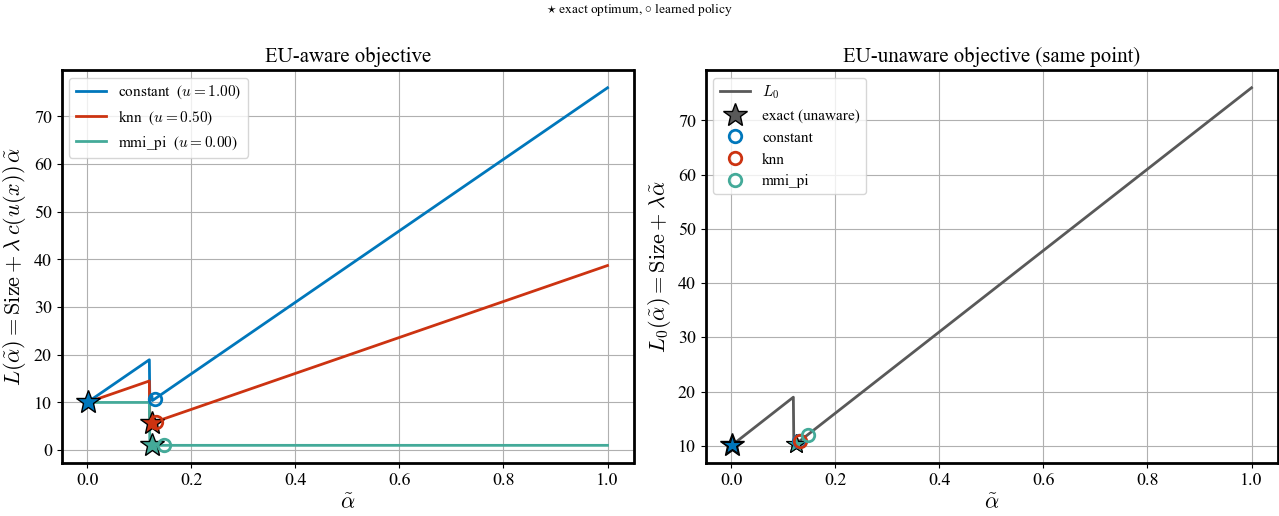

In [44]:
plt.rcParams.update(bundles.icml2024(usetex=False))
plt.rcParams.update({
    "axes.labelsize": 16, "axes.titlesize": 15,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 11, "lines.linewidth": 2, "axes.linewidth": 2,
})
colors = dict(zip(names, anet._PALETTE))

i_rep     = int(np.argsort(S_test)[len(S_test) // 2])
s_rep     = S_test_all[i_rep]
a_grid    = np.linspace(1.0 / (n_calib + 1) + 1e-3, 1.0, 1200)
size_grid = np.array([exact_size(Sigma_test, s_rep, n_calib, a) for a in a_grid], dtype=float)
L0_of     = lambda a: exact_size(Sigma_test, s_rep, n_calib, a) + lam * a

fig, axs = plt.subplots(1, 2, figsize=(13, 5.2))

# ---- left: EU-aware objective, one curve per uncertainty method ----
ax = axs[0]
for name in names:
    u_rep = float(comparison[name]["u"][i_rep])
    ax.plot(a_grid, size_grid + lam * c(u_rep) * a_grid, color=colors[name],
            label=rf"{name}  ($u={u_rep:.2f}$)")
    a_s, L_s = exact_min(Sigma_test, s_rep, n_calib, lam, w=c(u_rep))
    ax.plot(a_s, L_s, marker="*", ms=18, color=colors[name], mec="k", mew=1.0,
            ls="none", zorder=5)
    a_nn = float(comparison[name]["learned"]["alpha"][i_rep])
    ax.plot(a_nn, exact_size(Sigma_test, s_rep, n_calib, a_nn) + lam * c(u_rep) * a_nn,
            marker="o", ms=9, color="none", mec=colors[name], mew=2, ls="none", zorder=6)
ax.set_ylabel(r"$L(\tilde\alpha)=\mathrm{Size}+\lambda\,c(u(x))\,\tilde\alpha$")
ax.set_title("EU-aware objective")

# ---- right: old objective, single curve, every policy scored on it ----
ax = axs[1]
ax.plot(a_grid, size_grid + lam * a_grid, color="0.35", label=r"$L_0$")
a_u = float(comparison[names[0]]["unaware"]["alpha"][i_rep])
ax.plot(a_u, L0_of(a_u), marker="*", ms=18, color="0.35", mec="k", mew=1.0,
        ls="none", zorder=5, label="exact (unaware)")
for name in names:
    a_s = float(comparison[name]["exact"]["alpha"][i_rep])
    ax.plot(a_s, L0_of(a_s), marker="*", ms=15, color=colors[name], mec="k", mew=0.8,
            ls="none", zorder=5)
    a_nn = float(comparison[name]["learned"]["alpha"][i_rep])
    ax.plot(a_nn, L0_of(a_nn), marker="o", ms=9, color="none", mec=colors[name],
            mew=2, ls="none", zorder=6, label=name)
ax.set_ylabel(r"$L_0(\tilde\alpha)=\mathrm{Size}+\lambda\tilde\alpha$")
ax.set_title("EU-unaware objective (same point)")

for ax in axs:
    ax.set_xlabel(r"$\tilde\alpha$")
    ax.grid(True)
    ax.legend(frameon=True)
fig.suptitle(r"$\star$ exact optimum, $\circ$ learned policy", y=1.01)
plt.tight_layout()
plt.savefig(f"plots/exact_vs_learned_both_objectives_{dataname}.pdf", bbox_inches="tight")
plt.savefig(f"plots/exact_vs_learned_both_objectives_{dataname}.png", dpi=160, bbox_inches="tight")
plt.show()

In [52]:
import numpy as np
import pandas as pd
import pingouin as pg


# ============================================================
# SETTINGS
# ============================================================

# Choose the loss formulation:
# "loss0" = OLD loss
# "loss"  = NEW loss
LOSS_OUTCOME = "loss0"

# Set size is the primary outcome for RQ2
SIZE_OUTCOME = "size"

POLICIES = ["exact", "learned"]
METHODS = ["constant", "knn", "mmi_pi"]
GROUPS = ["low eu", "high eu"]


# ============================================================
# DATA SETUP
# ============================================================

# Assumes your existing variables:
#   comparison
#   names
#   n_test
#   EU_test
#
# and the following columns are available:
#   alpha, size, loss, loss0, miss

long = pd.DataFrame([
    {
        "point": i,
        "method": name,
        "policy": pol,
        "alpha": comparison[name][pol]["alpha"][i],
        "size": comparison[name][pol]["size"][i],
        "loss": comparison[name][pol]["loss"][i],
        "loss0": comparison[name][pol]["loss0"][i],
        "miss": comparison[name][pol]["miss"][i],
    }
    for name in names
    for pol in POLICIES
    for i in range(n_test)
])

long["group"] = np.where(
    EU_test[long["point"].to_numpy()],
    "high eu",
    "low eu"
)

# Make sure categorical ordering is consistent
long["method"] = pd.Categorical(
    long["method"],
    categories=METHODS,
    ordered=True
)

long["policy"] = pd.Categorical(
    long["policy"],
    categories=POLICIES,
    ordered=True
)

long["group"] = pd.Categorical(
    long["group"],
    categories=GROUPS,
    ordered=True
)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def print_section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def print_subsection(title):
    print("\n" + "-" * 70)
    print(title)
    print("-" * 70)


def pairwise_within_policy(data, dv, policy):
    """
    Planned pairwise method comparisons within one policy.
    Holm correction is applied across the three method comparisons.
    """

    d = data[data["policy"] == policy].copy()

    result = pg.pairwise_tests(
        data=d,
        dv=dv,
        within="method",
        subject="point",
        padjust="holm",
        effsize="hedges"
    )

    return result


def cell_means(data, dv):
    """
    Means, SDs, and N for method × policy × group.
    """

    return (
        data
        .groupby(
            ["method", "policy", "group"],
            observed=True
        )[dv]
        .agg(["mean", "std", "count"])
        .round(4)
    )


def eu_gaps(data, dv):
    """
    High-EU minus low-EU mean difference for every
    method × policy combination.
    """

    means = (
        data
        .groupby(
            ["method", "policy", "group"],
            observed=True
        )[dv]
        .mean()
        .unstack("group")
    )

    means["high_minus_low"] = (
        means["high eu"] - means["low eu"]
    )

    return means.round(4)


# ============================================================
# RQ1
#
# LOSS COMPARABILITY
#
# Question:
# Are losses reasonably comparable across methods, especially
# in the low-EU setting, and are exact and learned policies
# broadly similar in terms of loss?
#
# Important:
# Ordinary NHST tests whether there is evidence of a difference.
# A non-significant p-value does NOT establish equivalence.
# Therefore we report actual differences/effect sizes rather
# than interpreting p > .05 as "the methods are the same."
# ============================================================

print_section(
    f"RQ1: LOSS COMPARABILITY ({LOSS_OUTCOME})"
)


# ------------------------------------------------------------
# RQ1A. Overall descriptive cell means
# ------------------------------------------------------------

print_subsection(
    "RQ1A. Loss means by method × policy × EU group"
)

print(
    cell_means(long, LOSS_OUTCOME)
)


# ------------------------------------------------------------
# RQ1B. Method × policy repeated-measures ANOVA
#
# method and policy are both within-point factors.
# ------------------------------------------------------------

print_subsection(
    "RQ1B. Method × policy repeated-measures ANOVA"
)

loss_anova = pg.rm_anova(
    data=long,
    dv=LOSS_OUTCOME,
    within=["method", "policy"],
    subject="point",
    correction=True,
    effsize="np2"
)

print(loss_anova.round(4))


# ------------------------------------------------------------
# RQ1C. Planned method comparisons within EXACT
# ------------------------------------------------------------

print_subsection(
    "RQ1C. Planned method comparisons — EXACT policy"
)

exact_loss_pairs = pairwise_within_policy(
    long,
    LOSS_OUTCOME,
    "exact"
)

print(exact_loss_pairs.round(4))


# ------------------------------------------------------------
# RQ1D. Planned method comparisons within LEARNED
# ------------------------------------------------------------

print_subsection(
    "RQ1D. Planned method comparisons — LEARNED policy"
)

learned_loss_pairs = pairwise_within_policy(
    long,
    LOSS_OUTCOME,
    "learned"
)

print(learned_loss_pairs.round(4))


# ------------------------------------------------------------
# RQ1E. LOW-EU ONLY
#
# This is particularly important for your revised RQ1.
#
# We compare methods within low EU separately for exact and
# learned.
# ------------------------------------------------------------

print_subsection(
    "RQ1E. Method comparisons specifically in LOW-EU"
)

low_eu = long[long["group"] == "low eu"].copy()

print("\nLOW-EU cell means:")
print(
    low_eu
    .groupby(["method", "policy"], observed=True)[LOSS_OUTCOME]
    .agg(["mean", "std", "count"])
    .round(4)
)

print("\nLOW-EU — EXACT:")
low_exact_pairs = pairwise_within_policy(
    low_eu,
    LOSS_OUTCOME,
    "exact"
)
print(low_exact_pairs.round(4))

print("\nLOW-EU — LEARNED:")
low_learned_pairs = pairwise_within_policy(
    low_eu,
    LOSS_OUTCOME,
    "learned"
)
print(low_learned_pairs.round(4))


# ------------------------------------------------------------
# RQ1F. Exact vs learned within each method
#
# This directly addresses:
# "I hope learned and exact are generally similar."
# ------------------------------------------------------------

print_subsection(
    "RQ1F. EXACT vs LEARNED loss within each method"
)

policy_comparisons = []

for method in METHODS:

    d = long[long["method"] == method].copy()

    result = pg.pairwise_tests(
        data=d,
        dv=LOSS_OUTCOME,
        within="policy",
        subject="point",
        padjust="none",
        effsize="hedges"
    )

    result["method"] = method
    policy_comparisons.append(result)

policy_comparisons = pd.concat(
    policy_comparisons,
    ignore_index=True
)

print(
    policy_comparisons.round(4)
)


# ------------------------------------------------------------
# RQ1G. Exact vs learned descriptive differences
# ------------------------------------------------------------

print_subsection(
    "RQ1G. Descriptive learned - exact loss difference"
)

loss_policy_means = (
    long
    .groupby(
        ["method", "group", "policy"],
        observed=True
    )[LOSS_OUTCOME]
    .mean()
    .unstack("policy")
)

loss_policy_means["learned_minus_exact"] = (
    loss_policy_means["learned"]
    - loss_policy_means["exact"]
)

print(
    loss_policy_means.round(4)
)


# ============================================================
# RQ1 NOTE ON "SIMILARITY"
# ============================================================

print_subsection(
    "RQ1 INTERPRETATION NOTE"
)

print(
    """
For RQ1, do not interpret p > .05 as evidence that two methods
are equivalent.

If the substantive claim is that losses are "similar", the most
defensible approach is to define a practical equivalence margin
before looking at the results and then perform equivalence tests
(e.g. TOST).

The tables above therefore emphasize:
    1. actual mean differences,
    2. effect sizes,
    3. confidence intervals,
    4. and the inferential tests for differences.

A large sample can make very small differences statistically
significant, so practical magnitude matters.
"""
)


# ============================================================
# RQ2
#
# EU ADAPTIVITY — SET SIZE
#
# Hypothesis:
#
#   high EU -> larger sets
#   low EU  -> smaller sets
#
# and specifically:
#
#   constant should show the smallest high-vs-low EU difference.
#
# This is directional, but we will not force the data to support
# it. The observed EU gaps and method × EU interactions determine
# the conclusion.
# ============================================================

print_section(
    "RQ2: EU ADAPTIVITY — SET SIZE"
)


# ------------------------------------------------------------
# RQ2A. Descriptive set-size means
# ------------------------------------------------------------

print_subsection(
    "RQ2A. Set-size means by method × policy × EU group"
)

print(
    cell_means(long, SIZE_OUTCOME)
)


# ------------------------------------------------------------
# RQ2B. High-EU minus low-EU gaps
#
# This is the central descriptive quantity for your hypothesis.
# Positive = larger sets under high EU.
# ------------------------------------------------------------

print_subsection(
    "RQ2B. EU set-size gaps: HIGH EU - LOW EU"
)

size_gaps = eu_gaps(
    long,
    SIZE_OUTCOME
)

print(size_gaps)


# ------------------------------------------------------------
# RQ2C. Overall EU effect on set size
#
# Separate mixed ANOVAs are useful descriptively here, but
# they do NOT by themselves establish that one method has a
# different EU effect from another.
#
# We therefore run them separately by method.
# ------------------------------------------------------------

print_subsection(
    "RQ2C. EU effect within each method"
)

for method in METHODS:

    d = long[long["method"] == method].copy()

    print(f"\n--- {method.upper()} ---")

    aov = pg.mixed_anova(
        data=d,
        dv=SIZE_OUTCOME,
        within="policy",
        between="group",
        subject="point",
        correction=True,
        effsize="np2"
    )

    print(aov.round(4))


# ------------------------------------------------------------
# RQ2D. Direct method × EU-group interaction
#
# Do this separately for EXACT and LEARNED.
#
# This directly tests whether the high-vs-low EU set-size
# difference varies between methods under each policy.
# ------------------------------------------------------------

print_subsection(
    "RQ2D. METHOD × EU GROUP interaction within each policy"
)

method_group_results = {}

for policy in POLICIES:

    d = long[long["policy"] == policy].copy()

    aov = pg.mixed_anova(
        data=d,
        dv=SIZE_OUTCOME,
        within="method",
        between="group",
        subject="point",
        correction=True,
        effsize="np2"
    )

    method_group_results[policy] = aov

    print(f"\n--- {policy.upper()} ---")
    print(aov.round(4))


# ------------------------------------------------------------
# RQ2E. Direct THREE-WAY test
#
# We calculate:
#
#       learned set size - exact set size
#
# for each point × method.
#
# Then:
#
#   within  = method
#   between = EU group
#
# The resulting METHOD × GROUP interaction is the direct
# METHOD × GROUP × POLICY interaction from the original
# repeated-measures design.
# ------------------------------------------------------------

print_subsection(
    "RQ2E. DIRECT METHOD × GROUP × POLICY TEST"
)

size_policy_wide = (
    long
    .pivot_table(
        index=["point", "method", "group"],
        columns="policy",
        values=SIZE_OUTCOME,
        observed=True
    )
    .reset_index()
)

size_policy_wide["policy_diff"] = (
    size_policy_wide["learned"]
    - size_policy_wide["exact"]
)

print("\nPolicy difference = learned - exact:")
print(
    size_policy_wide
    .groupby(
        ["group", "method"],
        observed=True
    )["policy_diff"]
    .agg(["mean", "std", "count"])
    .round(4)
)

three_way_size = pg.mixed_anova(
    data=size_policy_wide,
    dv="policy_diff",
    within="method",
    between="group",
    subject="point",
    correction=True,
    effsize="np2"
)

print("\nThree-way test:")
print(three_way_size.round(4))


# ------------------------------------------------------------
# RQ2F. Direct high-vs-low tests within each method × policy
#
# These establish whether each method actually produces larger
# sets under high EU than low EU.
#
# Effect size is Cohen's d.
# ------------------------------------------------------------

print_subsection(
    "RQ2F. HIGH EU vs LOW EU set size within each method × policy"
)

eu_tests = []

for method in METHODS:

    for policy in POLICIES:

        d = long[
            (long["method"] == method) &
            (long["policy"] == policy)
        ].copy()

        high = d.loc[
            d["group"] == "high eu",
            SIZE_OUTCOME
        ].dropna()

        low = d.loc[
            d["group"] == "low eu",
            SIZE_OUTCOME
        ].dropna()

        test = pg.ttest(
            high,
            low,
            paired=False,
            alternative="two-sided"
        )

        test["method"] = method
        test["policy"] = policy
        test["high_mean"] = high.mean()
        test["low_mean"] = low.mean()
        test["EU_gap_high_minus_low"] = (
            high.mean() - low.mean()
        )

        eu_tests.append(test)

eu_tests = pd.concat(
    eu_tests,
    ignore_index=True
)

print(
    eu_tests[
        [
            "method",
            "policy",
            "high_mean",
            "low_mean",
            "EU_gap_high_minus_low",
            "T",
            "dof",
            "p_val",
            "cohen_d"
        ]
    ].round(4)
)


# ============================================================
# RQ2G. Compare the EU gaps directly
#
# This gives a very clear descriptive table for your actual
# hypothesis:
#
# "Does constant show the least high-EU adaptation?"
#
# We DO NOT declare a winner based on the descriptive ordering.
# The method × group interactions above are the inferential tests.
# ============================================================

print_subsection(
    "RQ2G. EU GAP COMPARISON"
)

gap_table = (
    long
    .groupby(
        ["method", "policy", "group"],
        observed=True
    )[SIZE_OUTCOME]
    .mean()
    .unstack("group")
)

gap_table["EU_gap_high_minus_low"] = (
    gap_table["high eu"] -
    gap_table["low eu"]
)

print(
    gap_table.round(4)
)


# ============================================================
# OPTIONAL: ALPHA
#
# Not part of the primary hypotheses, but useful as a secondary
# descriptive outcome if you want to understand why set sizes
# differ.
# ============================================================

print_section(
    "OPTIONAL SECONDARY OUTCOME: ALPHA"
)

print_subsection(
    "Alpha means by method × policy × EU group"
)

print(
    cell_means(long, "alpha")
)


print_subsection(
    "Alpha EU gaps: HIGH EU - LOW EU"
)

print(
    eu_gaps(long, "alpha")
)


# ============================================================
# FINAL SUMMARY TABLES
# ============================================================

print_section(
    "FINAL SUMMARY TABLES"
)


# ------------------------------------------------------------
# Loss summary
# ------------------------------------------------------------

print("\nLOSS CELL MEANS:")
print(
    long
    .groupby(
        ["method", "policy", "group"],
        observed=True
    )[LOSS_OUTCOME]
    .mean()
    .round(4)
)


# ------------------------------------------------------------
# Set-size summary
# ------------------------------------------------------------

print("\nSET SIZE CELL MEANS:")
print(
    long
    .groupby(
        ["method", "policy", "group"],
        observed=True
    )[SIZE_OUTCOME]
    .mean()
    .round(4)
)


print("\nSET SIZE EU GAPS (HIGH - LOW):")
print(
    eu_gaps(
        long,
        SIZE_OUTCOME
    )
)


print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)



RQ1: LOSS COMPARABILITY (loss0)

----------------------------------------------------------------------
RQ1A. Loss means by method × policy × EU group
----------------------------------------------------------------------
                             mean     std  count
method   policy  group                          
constant exact   low eu   10.0220  0.0516   1572
                 high eu  10.0607  0.0338   1428
         learned low eu   10.9752  0.4729   1572
                 high eu  11.3377  0.7430   1428
knn      exact   low eu   10.1338  0.2983   1572
                 high eu  10.0925  0.1371   1428
         learned low eu   11.0539  0.4197   1572
                 high eu  11.3929  0.7555   1428
mmi_pi   exact   low eu   10.5914  4.7399   1572
                 high eu  11.8591  8.6065   1428
         learned low eu   12.1355  0.9095   1572
                 high eu  12.4908  1.6390   1428

----------------------------------------------------------------------
RQ1B. Method × poli